# EE6024 Assignment 4 – Neonatal EEG Seizure Detection
## A Patient-Independent SVM-Based System



---
## 1. Summary

This report presents an automated neonatal EEG seizure detection system inspired by the ANSeR
algorithm (Temko et al., 2011; Greene et al., 2008). The system is fully **patient-independent**:
the test patient (EEG75) is never used in any part of the training process.

The pipeline has four stages:

1. **Segmentation** – continuous EEG divided into 8-second epochs (256 samples at 32 Hz) with 50% overlap.
2. **Feature extraction** – 9 features per channel per epoch selected from the best-performing
features identified in Greene et al. (2008): Line Length, RMS Amplitude, Nonlinear Energy,
Zero Crossings, Local Maxima/Minima, Total Power, Spectral Edge Frequency (90%), Wavelet Energy,
and Spectral Entropy.
3. **Classification** – a Support Vector Machine (SVM) with RBF kernel trained on all 12 training
patients. Patient independence is ensured by keeping EEG75 completely separate.
4. **Post-processing** – a symmetric moving-average filter smooths per-epoch probabilities before
thresholding to reduce isolated false positives.

The system is evaluated on EEG75 with sensitivity and specificity reported at the epoch level.


---
## 2. Imports and Configuration

In [ ]:
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt                              # PyWavelets - discrete wavelet transform
import time, warnings
from cuml.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve)
warnings.filterwarnings('ignore')

# ── Global constants ───────────────────────────────────────────────────────
FS         = 32    # Sampling frequency (Hz) - data downsampled to 32 Hz
EPOCH_LEN  = 256   # 8 s x 32 Hz = 256 samples per epoch
EPOCH_SEC  = 8
STEP       = 128   # 50% overlap between successive epochs

# 12 training patients - EEG75 is the test patient and is kept fully separate
PATIENT_IDS = ['eeg4','eeg5','eeg7','eeg13','eeg14',
               'eeg34','eeg36','eeg38','eeg39','eeg44',
               'eeg47','eeg51']

def eeg_path(pid):
    """Return file path for processed EEG CSV for a given patient ID."""
    return f'{pid}_Processed.csv'

def ann_path(pid):
    """Return file path for annotation CSV for a given patient ID."""
    return f'{pid}_Combined_Exper_Annotations.csv'

print(f"Training patients : {len(PATIENT_IDS)}")
print(f"Patient IDs       : {PATIENT_IDS}")
print(f"Epoch length      : {EPOCH_LEN} samples ({EPOCH_SEC} s at {FS} Hz)")
print(f"Step size         : {STEP} samples (50% overlap)")


Training patients : 12
Patient IDs       : ['eeg4', 'eeg5', 'eeg7', 'eeg13', 'eeg14', 'eeg34', 'eeg36', 'eeg38', 'eeg39', 'eeg44', 'eeg47', 'eeg51']
Epoch length      : 256 samples (8 s at 32 Hz)
Step size         : 128 samples (50% overlap)


---
## 3. Feature Extraction

### 3.1 Feature Selection

The ANSeR algorithm (Temko et al. 2011) uses 55 features across time domain, frequency domain
and entropy categories. Rather than implementing all 55, a subset of 9 features was selected largely
based on the individual feature performance analysis reported in Greene et al. (2008), who
evaluated 21 quantitative EEG features for neonatal seizure detection using ROC analysis and
a linear discriminant classifier.

Greene et al. explicitly identified the five best-performing individual features as:
**RMS Amplitude, Local Maxima and Minima, AR model fit, Line Length and Total Power**,
which together achieved 80.14% sensitivity and 78.96% specificity, only a marginal drop
from using all 21 features (81.08% / 82.23%). AR model fit was omitted here due to
implementation complexity. Four additional features were included to broaden coverage
across frequency domain and entropy categories.
| Feature | Category | Justification |
|---------|----------|---------------|
| Line Length | Time | Top 5 performer, Greene et al. (2008) |
| RMS Amplitude | Time | Best individual feature, Greene et al. (2008) |
| Nonlinear Energy | Time | Strong time-domain feature, Temko et al. (2011) |
| Zero Crossings | Time | Decreases during seizure|
| Local Maxima + Minima | Time | Top 5 performer, Greene et al. (2008) |
| Total Power | Frequency | Top 5 performer, Greene et al. (2008) |
| SEF90 | Frequency | Shifts down during seizure |
| Wavelet Energy (db4 L5) | Frequency | Captures seizure-specific 1-2 Hz band, Kitayama et al. (2003) |
| Spectral Entropy | Entropy | Decreases during seizure. |

Using 9 targeted features rather than the full set reduces computational cost and avoids
including redundant features. Greene et al. noted that many features essentially measure
the same underlying signal property, so a carefully selected subset is
preferable to an uncritical union of all available features.

### 3.2 Feature Definitions and Formulae


In [ ]:
def extract_features(epoch: np.ndarray) -> np.ndarray:
    """
    Compute 9 selected time- and frequency-domain features from one EEG epoch.

    Features are selected based on the best-performing individual features
    identified in Greene et al. (2008) and Temko et al. (2011).

    Parameters
    ----------
    epoch : np.ndarray, shape (EPOCH_LEN,)
        One epoch of EEG data in microvolts.

    Returns
    -------
    feats : np.ndarray, shape (9,)
        Feature vector containing the 9 selected features.
    """
    x = epoch.astype(float)
    N = len(x)
    feats = []

    # ── TIME DOMAIN ──────────────────────────────────────────────────────

    # 1. Line Length: L = sum|x(k+1) - x(k)|
    # Measures total variation of the signal. Increases during seizure as
    # both the amplitude and oscillation frequency of the EEG increase.
    feats.append(np.sum(np.abs(np.diff(x))))

    # 2. RMS Amplitude: A = sqrt(1/N * sum(x^2(k)))
    # Root mean square amplitude; equivalent to the cerebral function monitor
    # (CFM) output.
    feats.append(np.sqrt(np.mean(x**2)))

    # 3. Nonlinear Energy: mean of NLE(k) = x^2(k) - x(k-1)*x(k+1)
    # Instantaneous energy operator proposed by D'Alessandro et al. (2003).
    # Emphasises oscillatory components characteristic of seizure activity
    # by combining amplitude and frequency information in a single measure.
    feats.append(np.mean(x[1:-1]**2 - x[:-2]*x[2:]))

    # 4. Zero Crossings: number of positive zero crossings (negative to positive)
    # The rate of zero crossings relates to the dominant frequency of the signal.
    # Decreases during neonatal seizures as the dominant frequency drops from
    # normal background levels.
    feats.append(int(np.sum((x[:-1] < 0) & (x[1:] >= 0))))

    # 5. Local Maxima + Minima: total count of turning points in the epoch
    # Counts the number of local peaks and troughs. Closely related to zero
    # crossings but captures oscillatory behaviour independently of amplitude.
    feats.append(int(np.sum((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))) +
                 int(np.sum((x[1:-1] < x[:-2]) & (x[1:-1] < x[2:]))))

    # ── FREQUENCY DOMAIN ─────────────────────────────────────────────────

    # Periodogram: pi = (1/N)|DFT(x)|^2
    # One-sided power spectral density estimate using the DFT.
    # Frequency resolution df = Fs/N = 32/256 = 0.125 Hz per bin.
    # Bins 0 to N/2-1 cover the range 0 to 16 Hz.
    pi    = (np.abs(np.fft.rfft(x, n=N))**2) / N
    pi    = pi[:N//2]                          # one-sided spectrum
    freqs = np.arange(N//2) * (FS / N)        # frequency axis in Hz
    tp    = np.sum(pi)                         # total power

    # 6. Total Power: sum of all periodogram bins
    # Integral of the one-sided PSD; increases substantially during seizure
    # due to the high-amplitude rhythmic activity.
    feats.append(tp)

    # 7. Spectral Edge Frequency at 90% (SEF90)
    # The frequency below which 90% of the total spectral power lies.
    # Shifts significantly downward during neonatal seizures as power
    # concentrates in lower frequency bands.
    cumsum = np.cumsum(pi)
    idx = int(np.searchsorted(cumsum, 0.90 * tp))
    feats.append(float(freqs[min(idx, len(freqs) - 1)]))

    # 8. Wavelet Energy - 5th level detail coefficients, Daubechies-4 wavelet
    # The EEG is decomposed using pywt.wavedec with the db4 wavelet to 5 levels.
    # pywt.wavedec returns [approximation, detail_5, detail_4, ..., detail_1].
    # At fs=32 Hz, the 5th level detail band corresponds to approximately 1-2 Hz,
    # which is the frequency range most strongly modulated by neonatal seizures
    # (Kitayama et al. 2003). The energy of these coefficients
    # therefore provides a seizure-specific frequency-domain feature.
    coeffs = pywt.wavedec(x, 'db4', level=5)
    feats.append(float(np.sum(coeffs[1]**2)))

    # ── ENTROPY ──────────────────────────────────────────────────────────

    # 9. Spectral Entropy: H_s = -sum(p_f * log(p_f))
    # The normalised PSD p_f = pi/sum(pi) is treated as a probability
    # distribution over frequencies. The entropy measures the flatness or
    # disorder of the spectrum. A flat spectrum (broadband noise) has high
    # entropy; a peaked spectrum (rhythmic seizure) has low entropy.
    # Decreases during neonatal seizures.
    pn = pi / tp if tp > 1e-12 else np.ones_like(pi) / len(pi)
    pn = pn / pn.sum()
    feats.append(float(-np.sum(pn * np.log(pn + 1e-12))))

    return np.array(feats, dtype=float)


def epoch_label(start: int, ann: np.ndarray, ch: int) -> int:
    """
    Assign a binary label to one epoch using majority-vote over the
    per-second annotations covering the epoch window.

    Parameters
    ----------
    start : int        - first sample index of the epoch
    ann   : np.ndarray - shape (N_seconds, N_channels), 1 Hz binary labels
                         where 0 = non-seizure, 1 = seizure
    ch    : int        - channel index

    Returns 1 (seizure) if >50% of covered seconds are labelled seizure,
    else 0 (non-seizure).
    """
    s = start // FS
    e = min((start + EPOCH_LEN) // FS, len(ann))
    return int(ann[s:e, ch].mean() > 0.5) if e > s else 0


# Sanity check on a random epoch
fv = extract_features(np.random.randn(EPOCH_LEN))
print(f"Feature vector length : {len(fv)}  (expected 9)")
print(f"Any NaN / Inf         : {np.any(np.isnan(fv))} / {np.any(np.isinf(fv))}")
print(f"\nFeatures computed:")
FEATURE_NAMES = ['Line Length', 'RMS Amplitude', 'Nonlinear Energy',
                 'Zero Crossings', 'Local Max+Min', 'Total Power',
                 'SEF90', 'Wavelet Energy', 'Spectral Entropy']
for i, name in enumerate(FEATURE_NAMES):
    print(f"  [{i}] {name}")


Feature vector length : 9  (expected 9)
Any NaN / Inf         : False / False

Features computed:
  [0] Line Length
  [1] RMS Amplitude
  [2] Nonlinear Energy
  [3] Zero Crossings
  [4] Local Max+Min
  [5] Total Power
  [6] SEF90
  [7] Wavelet Energy
  [8] Spectral Entropy


---
## 4. Building the Training Dataset

Features and labels are extracted from every 8-second epoch of all 12 training recordings.
Each channel of each recording is treated as an independent sample, following Temko et al. (2011),
who trained a single classifier on epochs from all channels of all training patients.

The annotation files label the EEG at 1 Hz (one label per second). Each 8-second epoch
therefore spans 8 annotation seconds. A majority-vote rule is applied: if more than 50%
of the seconds within an epoch are annotated as seizure, the epoch receives a seizure label.


In [ ]:
X_train_list = []
y_train_list = []
t_start = time.time()

for pid in PATIENT_IDS:
    # Load 8-channel EEG (N_samples x 8) and 1 Hz annotations (N_seconds x 8)
    # The EEG has been pre-processed: bandpass filtered and downsampled to 32 Hz
    eeg = pd.read_csv(eeg_path(pid)).values.astype(float)
    ann = pd.read_csv(ann_path(pid), index_col=0).values.astype(float)

    n_before = len(X_train_list)

    # Slide a window of EPOCH_LEN samples with STEP overlap across every channel
    for ch in range(eeg.shape[1]):
        for s in range(0, len(eeg) - EPOCH_LEN + 1, STEP):
            ep    = eeg[s:s + EPOCH_LEN, ch]
            feats = extract_features(ep)
            # Discard epochs with invalid feature values
            if np.any(np.isnan(feats)) or np.any(np.isinf(feats)):
                continue
            X_train_list.append(feats)
            y_train_list.append(epoch_label(s, ann, ch))

    n_added  = len(X_train_list) - n_before
    sz_rate  = np.mean(y_train_list[-n_added:]) * 100
    print(f"  {pid:6s}: {n_added:6d} epochs  |  seizure rate = {sz_rate:.1f}%")

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

elapsed       = time.time() - t_start
total_seizure = y_train.sum()

print(f"\nFeature extraction complete in {elapsed:.1f} s")
print(f"Total training epochs  : {len(y_train):,}")
print(f"Seizure epochs         : {int(total_seizure):,} ({total_seizure/len(y_train)*100:.1f}%)")
print(f"Non-seizure epochs     : {int((y_train==0).sum()):,}")
print(f"\nClass imbalance ratio  : 1:{int((y_train==0).sum()/total_seizure):.0f} "
      f"(seizure:non-seizure)")


  eeg4  :   6808 epochs  |  seizure rate = 1.7%
  eeg5  :   7640 epochs  |  seizure rate = 5.3%
  eeg7  :   7264 epochs  |  seizure rate = 1.5%
  eeg13 :  30784 epochs  |  seizure rate = 4.4%
  eeg14 :   7408 epochs  |  seizure rate = 38.2%
  eeg34 :  12936 epochs  |  seizure rate = 4.7%
  eeg36 :  10120 epochs  |  seizure rate = 1.0%
  eeg38 :  12144 epochs  |  seizure rate = 6.6%
  eeg39 :   9216 epochs  |  seizure rate = 15.4%
  eeg44 :   6672 epochs  |  seizure rate = 3.8%
  eeg47 :   7168 epochs  |  seizure rate = 2.4%
  eeg51 :   9360 epochs  |  seizure rate = 2.6%

Feature extraction complete in 55.6 s
Total training epochs  : 127,520
Seizure epochs         : 8,416 (6.6%)
Non-seizure epochs     : 119,104

Class imbalance ratio  : 1:14 (seizure:non-seizure)


### 4.1 Training Dataset Summary

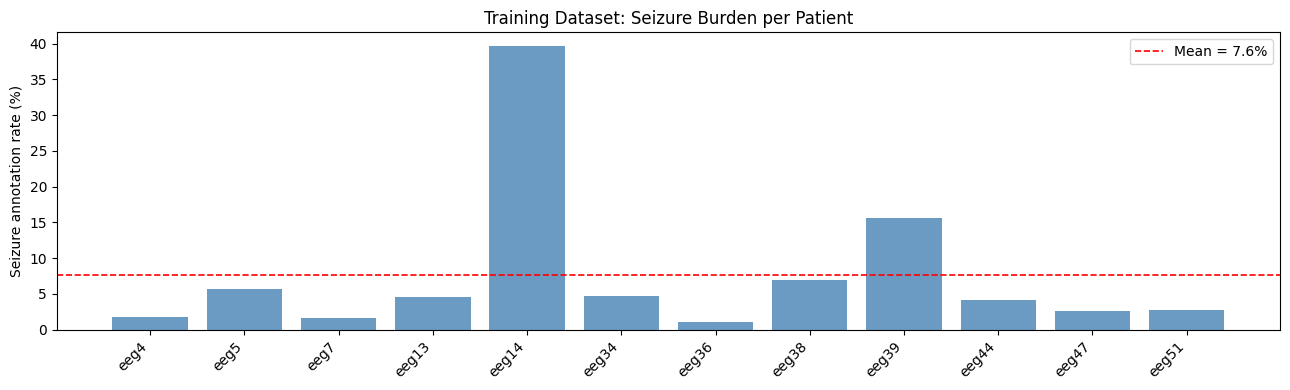

Seizure burden varies considerably across patients.
This is consistent with Greene et al. (2008) who noted that high-amplitude
generalised seizures are easier to detect than low-amplitude focal seizures.


In [ ]:
# Per-patient seizure burden from annotation files
per_patient_sz = []
for pid in PATIENT_IDS:
    ann = pd.read_csv(ann_path(pid), index_col=0).values.astype(float)
    per_patient_sz.append(ann.mean() * 100)

x = np.arange(len(PATIENT_IDS))
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x, per_patient_sz, color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(PATIENT_IDS, rotation=45, ha='right')
ax.set_ylabel('Seizure annotation rate (%)')
ax.set_title('Training Dataset: Seizure Burden per Patient')
ax.axhline(np.mean(per_patient_sz), color='red', ls='--', lw=1.2,
           label=f'Mean = {np.mean(per_patient_sz):.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('fig_dataset_summary.png', dpi=120)
plt.show()

print("Seizure burden varies considerably across patients.")
print("This is consistent with Greene et al. (2008) who noted that high-amplitude")
print("generalised seizures are easier to detect than low-amplitude focal seizures.")


---
## 5. SVM Classifier

### 5.1 Classifier Choice and Justification

A **Support Vector Machine (SVM)** with a Radial Basis Function (RBF) kernel is used,
directly following the ANSeR algorithm (Temko et al. 2011), which demonstrated
state-of-the-art neonatal seizure detection performance with this approach.

**Why SVM?**
SVMs find the maximum-margin hyperplane separating the two classes in feature space.
The margin maximisation provides good generalisation to unseen patients. The RBF kernel:

K(xi, xj) = exp(−γ‖xi − xj‖²)

implicitly maps features into a high-dimensional space where a linear hyperplane can
separate non-linearly separable classes. This is important because the relationship
between EEG features and seizure/non-seizure labels is non-linear.

**Key parameters:**
- `C=1.0` – regularisation parameter controlling the trade-off between maximising the
  margin and minimising training errors. C=1.0 is the standard default providing a
  balance between bias and variance.
- `gamma='scale'` – sets γ = 1/(n_features × Var(X)), which adapts the kernel width
  to the scale of the input features.
- `probability=True` – enables Platt scaling: a sigmoid function is fitted to the raw
  SVM decision values to produce calibrated posterior probabilities P(seizure|features).
  This is required for the moving-average post-processing step.
- `class_weight='balanced'` – compensates for the severe class imbalance in the training
  data. Sets the weight for each class to w_k = n_samples / (n_classes × n_k), so
  misclassifying a seizure epoch is penalised more heavily than misclassifying a
  non-seizure epoch. Without this, the classifier would be biased toward predicting
  non-seizure for every epoch, achieving high accuracy but near-zero sensitivity.

**Feature normalisation:**
`StandardScaler` standardises each of the 9 features to zero mean and unit variance
using statistics computed from the training data only. This is essential because the
SVM RBF kernel computes Euclidean distances between feature vectors. Features with
large absolute values (e.g. Total Power in μV²) would otherwise completely dominate
features with small values (e.g. Spectral Entropy). The scaler is fitted on training
data and applied without re-fitting to the test data, preventing any information leakage.

### 5.2 Patient Independence

Training data comes from patients eeg4, eeg5, eeg7, eeg13, eeg14, eeg34, eeg36, eeg38,
eeg39, eeg44, eeg47, eeg51. The test patient (EEG75) is a completely different individual
whose data is never used in any training, scaling or preprocessing step.

One validation strategy would be leave-one-out cross-validation (LOO-CV) across
all 12 training patients, as employed by Temko et al. (2011) and Greene et al. (2008).
This would involve training 12 separate SVMs, each on 11 patients and testing on the
remaining one, rotating through all combinations. This was found to be computationally
prohibitive. Instead, the model is trained on all 12 patients and evaluated on the
completely separate test patient EEG75.

In [ ]:
# ── Feature normalisation ─────────────────────────────────────────────────
# StandardScaler.fit_transform:
#   1. Computes mean and std for each of the 9 feature dimensions from X_train
#   2. Returns (X_train - mean) / std for each feature
# The fitted scaler object is saved so the identical transformation can be
# applied to the test data using scaler.transform() (never re-fitted on test)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)

print(f"Training set shape after scaling : {X_train_sc.shape}")
print(f"Feature means (should be ~0)     : min={X_train_sc.mean(axis=0).min():.4f}, "
      f"max={X_train_sc.mean(axis=0).max():.4f}")
print(f"Feature stds  (should be ~1)     : min={X_train_sc.std(axis=0).min():.4f}, "
      f"max={X_train_sc.std(axis=0).max():.4f}")

# ── Train SVM ─────────────────────────────────────────────────────────────
print("\nTraining SVM on all 12 patients ...")
t0 = time.time()

svm = SVC(
    C=1.0,                    # regularisation: margin vs training error trade-off
    kernel='rbf',             # Gaussian RBF kernel for non-linear class boundaries
    gamma='scale',            # gamma = 1/(n_features * Var(X))
    probability=True,         # Platt scaling for calibrated probabilities
    class_weight='balanced',  # compensate for seizure/non-seizure imbalance
    random_state=42           # reproducibility
)
svm.fit(X_train_sc, y_train)

print(f"Training complete in {time.time()-t0:.1f} s")
print(f"Number of support vectors : {svm.n_support_}")


Training set shape after scaling : (127520, 9)
Feature means (should be ~0)     : min=-0.0000, max=0.0000
Feature stds  (should be ~1)     : min=1.0000, max=1.0000

Training SVM on all 12 patients ...
Training complete in 28.0 s
Number of support vectors : 37011


### 5.3 Feature Discrimination

The chart below shows the normalised mean difference between seizure and non-seizure
epochs for each of the 9 features in the training data. Total Power, Nonlinear Energy, Wavelet Energy, RMS Amplitude and Line Length are the best performing features that discriminate considerably between classes.


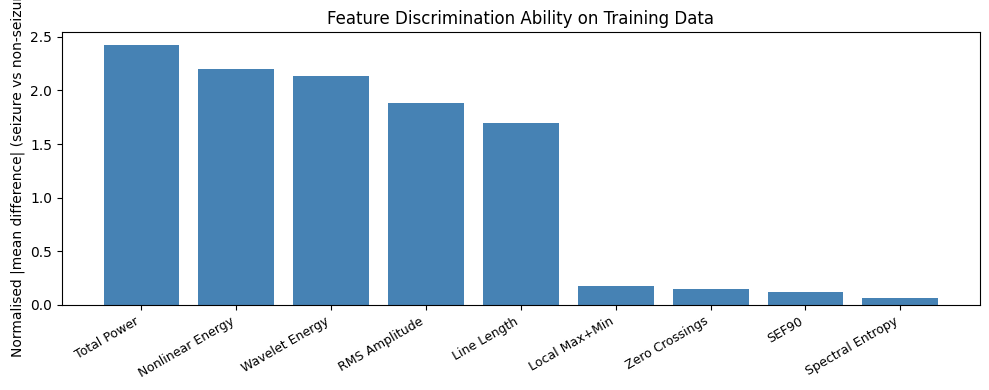

Feature discrimination ranking (training data):
  1. Total Power           score=2.421  (higher during seizure)
  2. Nonlinear Energy      score=2.197  (higher during seizure)
  3. Wavelet Energy        score=2.132  (higher during seizure)
  4. RMS Amplitude         score=1.887  (higher during seizure)
  5. Line Length           score=1.697  (higher during seizure)
  6. Local Max+Min         score=0.177  (lower during seizure)
  7. Zero Crossings        score=0.151  (lower during seizure)
  8. SEF90                 score=0.118  (lower during seizure)
  9. Spectral Entropy      score=0.068  (lower during seizure)


In [ ]:
# Normalised mean difference: |mean_seizure - mean_nonseizure| / |mean_nonseizure|
# Higher value = more discriminative feature
sz_mean   = X_train[y_train == 1].mean(axis=0)
non_mean  = X_train[y_train == 0].mean(axis=0)
norm_diff = np.abs(sz_mean - non_mean) / (np.abs(non_mean) + 1e-6)
order     = np.argsort(norm_diff)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(FEATURE_NAMES)), norm_diff[order], color='steelblue')
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in order], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Normalised |mean difference| (seizure vs non-seizure)')
ax.set_title('Feature Discrimination Ability on Training Data')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=120)
plt.show()

print("Feature discrimination ranking (training data):")
for rank, idx in enumerate(order):
    direction = "higher" if sz_mean[idx] > non_mean[idx] else "lower"
    print(f"  {rank+1}. {FEATURE_NAMES[idx]:20s}  score={norm_diff[idx]:.3f}  "
          f"({direction} during seizure)")


---
## 6. Classification of Test Recording (EEG75)

The trained SVM is applied to the completely independent test recording EEG75 (single
channel Cz-C3). The same 9 features are extracted from each epoch, scaled using the
scaler fitted on training data, and passed to the SVM to obtain a per-epoch probability
of seizure.


In [ ]:
# ── Load test data ────────────────────────────────────────────────────────
# EEG75 is a single-channel recording; shape (N_samples, 1)
# The annotation file has shape (N_seconds, 1) at 1 Hz
eeg_test = pd.read_csv('Test-EEG75_Cz-C3_Processed.csv',
                        index_col=0).values.astype(float)
ann_test = pd.read_csv('Test-Annotation_Cz-C3-EEG75.csv',
                        index_col=0).values.astype(float)

print(f"Test EEG      : {eeg_test.shape}  ({eeg_test.shape[0]/FS:.0f} s)")
print(f"Test Ann      : {ann_test.shape}")
print(f"Seizure burden: {ann_test.mean()*100:.1f}%")

# ── Extract test features ─────────────────────────────────────────────────
# The same extract_features() function is used as for training,
# producing the identical 9-feature vector for each epoch
X_test_list, y_test_list, t_epoch = [], [], []

for s in range(0, len(eeg_test) - EPOCH_LEN + 1, STEP):
    ep    = eeg_test[s:s + EPOCH_LEN, 0]
    feats = extract_features(ep)
    if np.any(np.isnan(feats)) or np.any(np.isinf(feats)):
        continue
    sec_s = s // FS
    sec_e = min((s + EPOCH_LEN) // FS, len(ann_test))
    label = int(ann_test[sec_s:sec_e, 0].mean() > 0.5)
    X_test_list.append(feats)
    y_test_list.append(label)
    t_epoch.append(s / FS)

X_test  = np.array(X_test_list)
y_test  = np.array(y_test_list)
t_epoch = np.array(t_epoch)

print(f"\nTest epochs        : {len(y_test)}")
print(f"Seizure epochs     : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Apply the scaler fitted on training data - never re-fit on test data
# This ensures no information from the test set influences the scaling
X_test_sc  = scaler.transform(X_test)

# predict_proba returns [P(non-seizure), P(seizure)] per epoch
# Index 1 selects the seizure probability
proba_test = svm.predict_proba(X_test_sc)[:, 1]

print(f"\nRaw predictions (no post-processing): "
      f"{(proba_test >= 0.5).sum()} seizure epochs")


Test EEG      : (126032, 1)  (3938 s)
Test Ann      : (3952, 1)
Seizure burden: 5.6%

Test epochs        : 983
Seizure epochs     : 53 (5.4%)

Raw predictions (no post-processing): 122 seizure epochs


---
## 7. Post-Processing

A **symmetric moving-average filter (MAF)** is applied to the sequence of epoch
probabilities, following Temko et al. (2011).

**Purpose:** Individual epochs can be misclassified due to brief artefacts or
momentary background fluctuations that resemble seizure features. The MAF smooths
the probability sequence over time so that isolated spikes are attenuated, while
sustained regions of high probability, corresponding to true seizures, are
preserved. It effectively acts as an implicit minimum-duration criterion.

**Definition:**

y[i] = (1 / (2N+1)) × Σ x[i+j]  for j = -N to N

A half-window of N=3 epochs is used (full window = 7 epochs = 28 seconds, given
the 4-second step size between epochs).

A threshold of 0.5 is applied to the smoothed probabilities to produce the final
binary seizure/non-seizure decision per epoch.


In [29]:
HALF_WIN  = 3    # filter extends ±3 epochs = ±12 s either side of each epoch
THRESHOLD = 0.5  # probability threshold for seizure/non-seizure decision

# np.convolve with a rectangular window of length 2*HALF_WIN+1.
# Dividing by the window length makes it an averaging (not summing) operation.
# mode='same' keeps the output the same length as the input sequence.
win          = 2 * HALF_WIN + 1
proba_smooth = np.convolve(proba_test, np.ones(win) / win, mode='same')

# Apply threshold to produce binary prediction per epoch
# 1 = seizure detected, 0 = non-seizure
y_pred = (proba_smooth >= THRESHOLD).astype(int)

print(f"Post-processing: MAF window = {win} epochs = {win * STEP / FS:.0f} s total")
print(f"Threshold       : {THRESHOLD}")
print(f"Before MAF: {(proba_test >= THRESHOLD).sum()} seizure epoch predictions")
print(f"After  MAF: {y_pred.sum()} seizure epoch predictions")
print(f"(Reduction of {(proba_test >= THRESHOLD).sum() - y_pred.sum()} "
      f"epochs = false positives removed by smoothing)")


Post-processing: MAF window = 7 epochs = 28 s total
Threshold       : 0.5
Before MAF: 122 seizure epoch predictions
After  MAF: 104 seizure epoch predictions
(Reduction of 18 epochs = false positives removed by smoothing)


---
## 8. Performance Metrics

### 8.1 Choice and Justification of Metrics

**Sensitivity** (True Positive Rate) – the fraction of true seizure epochs correctly detected:

Sensitivity = TP / (TP + FN)

**Specificity** (True Negative Rate) – the fraction of non-seizure epochs correctly rejected:

Specificity = TN / (TN + FP)

**Why sensitivity and specificity?**

These two metrics are chosen because they independently capture the two types of
classification error, which have very different clinical consequences:

- A **missed seizure** (False Negative) means the system fails to alert clinicians
  to a seizure that is occurring, potentially resulting in delayed or absent treatment
  and consequent brain damage. High sensitivity is therefore clinically essential.
- A **false alarm** (False Positive) means the system incorrectly identifies normal
  background EEG as a seizure, potentially causing unnecessary intervention and
  contributing to alert fatigue among clinical staff.

Accuracy alone is not an appropriate metric here because the dataset is heavily
imbalanced as seizure epochs account for only a small fraction of the total. A
classifier that predicts non-seizure for every epoch would achieve high accuracy
but zero sensitivity, which would be clinically useless.

The **ROC AUC** (Area Under the Receiver Operating Characteristic curve) is also
reported as a threshold-independent summary measure. The ROC curve plots sensitivity
against (1 - specificity) as the decision threshold is varied from 0 to 1. An AUC
of 1.0 represents perfect discrimination; 0.5 represents a random classifier.


In [30]:
# ── Confusion matrix ──────────────────────────────────────────────────────
# confusion_matrix with labels=[0,1] guarantees the order:
# [[TN, FP],
#  [FN, TP]]
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp_val = cm.ravel()

# Sensitivity = TP / (TP + FN)
# Fraction of actual seizure epochs that the system correctly detected
sensitivity = tp_val / (tp_val + fn) if (tp_val + fn) > 0 else 0.0

# Specificity = TN / (TN + FP)
# Fraction of actual non-seizure epochs that the system correctly rejected
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# Accuracy = (TP + TN) / total
# Overall fraction correct - reported for completeness but not the primary metric
accuracy = (tp_val + tn) / len(y_test)

# ROC AUC - threshold-independent measure of discrimination ability
auc = roc_auc_score(y_test, proba_smooth)

print("=" * 47)
print("  EPOCH-BASED PERFORMANCE ON EEG75 (TEST)")
print("=" * 47)
print(f"  True  Positives (TP) : {tp_val:5d}  (seizure correctly detected)")
print(f"  False Positives (FP) : {fp:5d}  (non-seizure misclassified as seizure)")
print(f"  False Negatives (FN) : {fn:5d}  (seizure missed)")
print(f"  True  Negatives (TN) : {tn:5d}  (non-seizure correctly rejected)")
print("-" * 47)
print(f"  Sensitivity          : {sensitivity*100:.1f}%")
print(f"  Specificity          : {specificity*100:.1f}%")
print(f"  Accuracy             : {accuracy*100:.1f}%")
print(f"  ROC AUC              : {auc:.3f}")
print("=" * 47)


  EPOCH-BASED PERFORMANCE ON EEG75 (TEST)
  True  Positives (TP) :    34  (seizure correctly detected)
  False Positives (FP) :    70  (non-seizure misclassified as seizure)
  False Negatives (FN) :    19  (seizure missed)
  True  Negatives (TN) :   860  (non-seizure correctly rejected)
-----------------------------------------------
  Sensitivity          : 64.2%
  Specificity          : 92.5%
  Accuracy             : 90.9%
  ROC AUC              : 0.952


### 8.2 Classification vs Ground Truth Plot

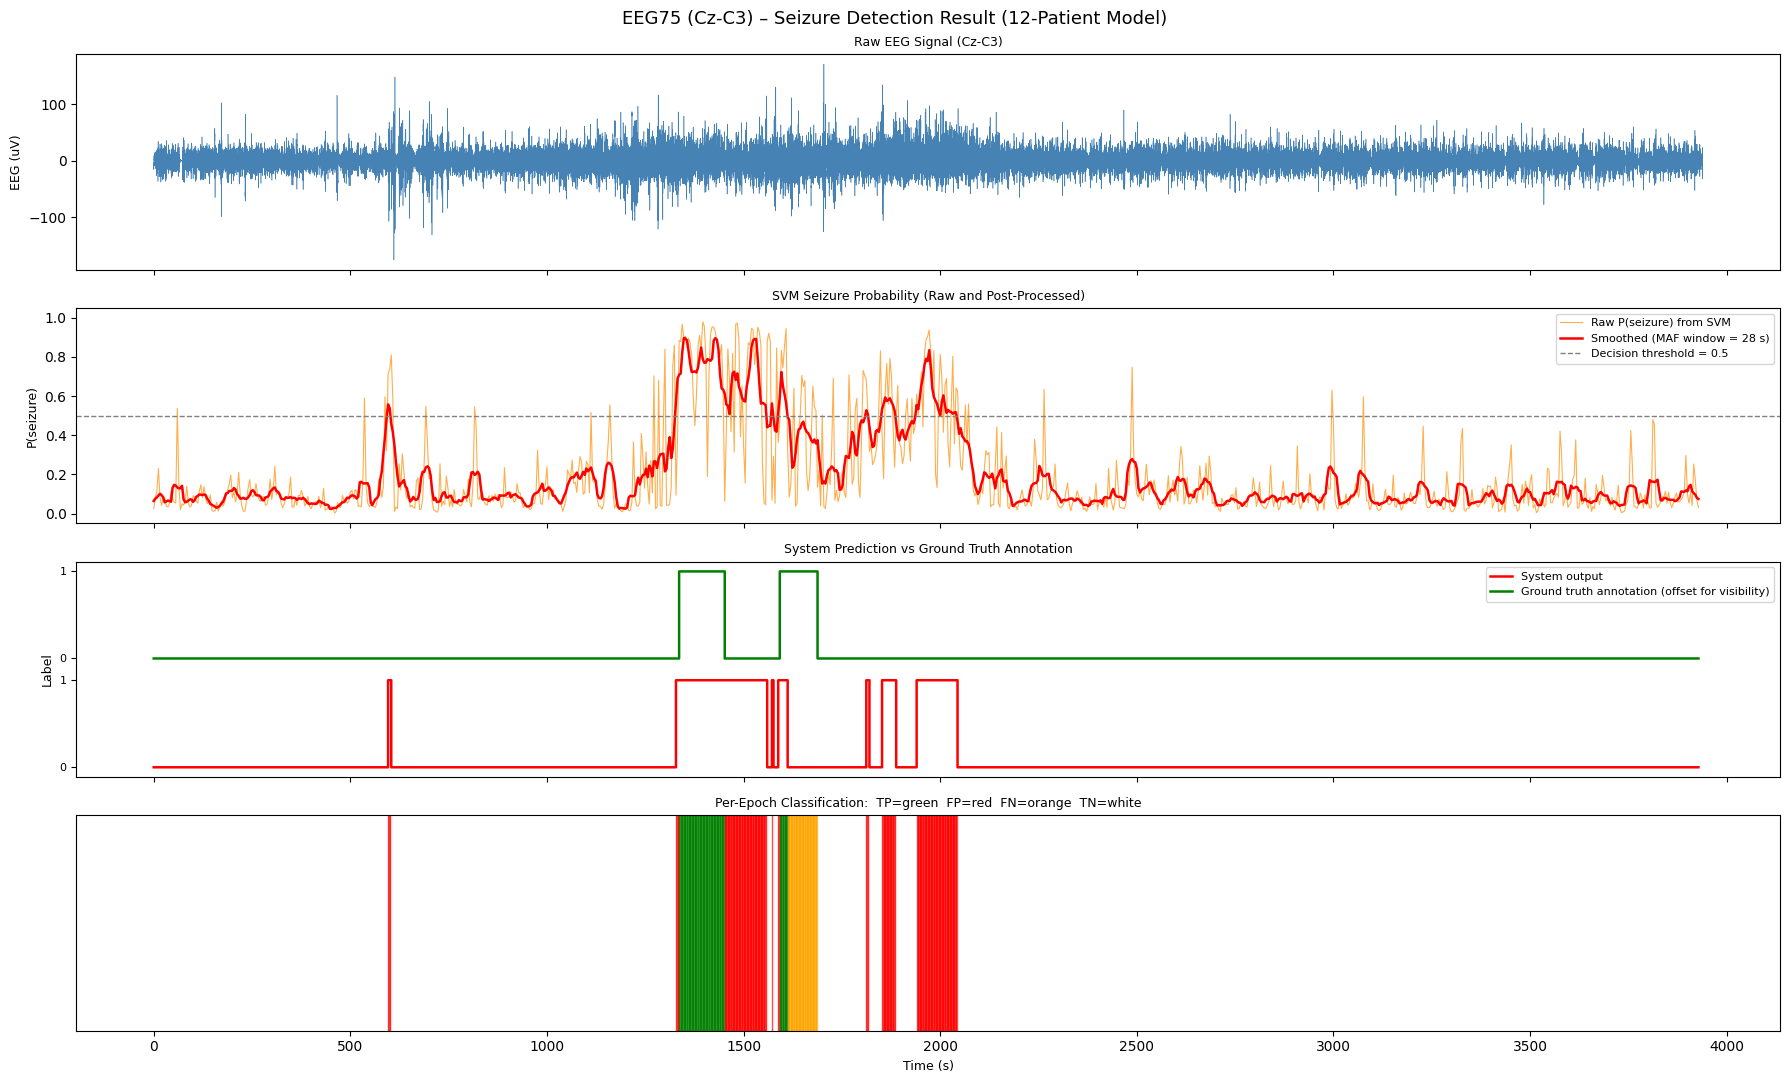

Sensitivity: 64.2%   Specificity: 92.5%   AUC: 0.952


In [31]:
fig, axes = plt.subplots(4, 1, figsize=(18, 11), sharex=True)
fig.suptitle('EEG75 (Cz-C3) – Seizure Detection Result (12-Patient Model)', fontsize=13)

# Panel 1: raw EEG signal
ax = axes[0]
t_full = np.arange(len(eeg_test)) / FS
ax.plot(t_full, eeg_test[:, 0], color='steelblue', lw=0.4)
ax.set_ylabel('EEG (uV)', fontsize=9)
ax.set_title('Raw EEG Signal (Cz-C3)', fontsize=9)

# Panel 2: seizure probability before and after MAF smoothing
ax = axes[1]
ax.plot(t_epoch, proba_test,   color='darkorange', lw=0.8, alpha=0.7,
        label='Raw P(seizure) from SVM')
ax.plot(t_epoch, proba_smooth, color='red', lw=1.8,
        label=f'Smoothed (MAF window = {win * STEP / FS:.0f} s)')
ax.axhline(THRESHOLD, color='grey', ls='--', lw=1,
           label=f'Decision threshold = {THRESHOLD}')
ax.set_ylabel('P(seizure)', fontsize=9)
ax.set_ylim(-0.05, 1.05)
ax.set_title('SVM Seizure Probability (Raw and Post-Processed)', fontsize=9)
ax.legend(fontsize=8, loc='upper right')

# Panel 3: binary prediction vs ground truth annotation
ax = axes[2]
ax.step(t_epoch, y_pred,        color='red',   lw=1.8, where='post',
        label='System output')
ax.step(t_epoch, y_test + 1.25, color='green', lw=1.8, where='post',
        label='Ground truth annotation (offset for visibility)')
ax.set_yticks([0, 1, 1.25, 2.25])
ax.set_yticklabels(['0', '1', '0', '1'], fontsize=8)
ax.set_ylabel('Label', fontsize=9)
ax.set_title('System Prediction vs Ground Truth Annotation', fontsize=9)
ax.legend(fontsize=8, loc='upper right')

# Panel 4: per-epoch outcome colour map
# Each epoch is coloured by its classification outcome:
# Green = True Positive (seizure correctly detected)
# Red   = False Positive (non-seizure incorrectly flagged)
# Orange = False Negative (seizure missed)
# White = True Negative (non-seizure correctly rejected)
ax = axes[3]
colour_map = {(1,1): 'green', (1,0): 'red', (0,1): 'orange', (0,0): 'white'}
for i, t in enumerate(t_epoch):
    c = colour_map[(int(y_pred[i]), int(y_test[i]))]
    ax.axvspan(t, t + STEP/FS, color=c, alpha=0.7)
ax.set_xlabel('Time (s)', fontsize=9)
ax.set_yticks([])
ax.set_title('Per-Epoch Classification:  TP=green  FP=red  FN=orange  TN=white',
             fontsize=9)

plt.tight_layout()
plt.savefig('fig_eeg75_result.png', dpi=120)
plt.show()
print(f"Sensitivity: {sensitivity*100:.1f}%   "
      f"Specificity: {specificity*100:.1f}%   "
      f"AUC: {auc:.3f}")


### 8.3 ROC Curve and Confusion Matrix

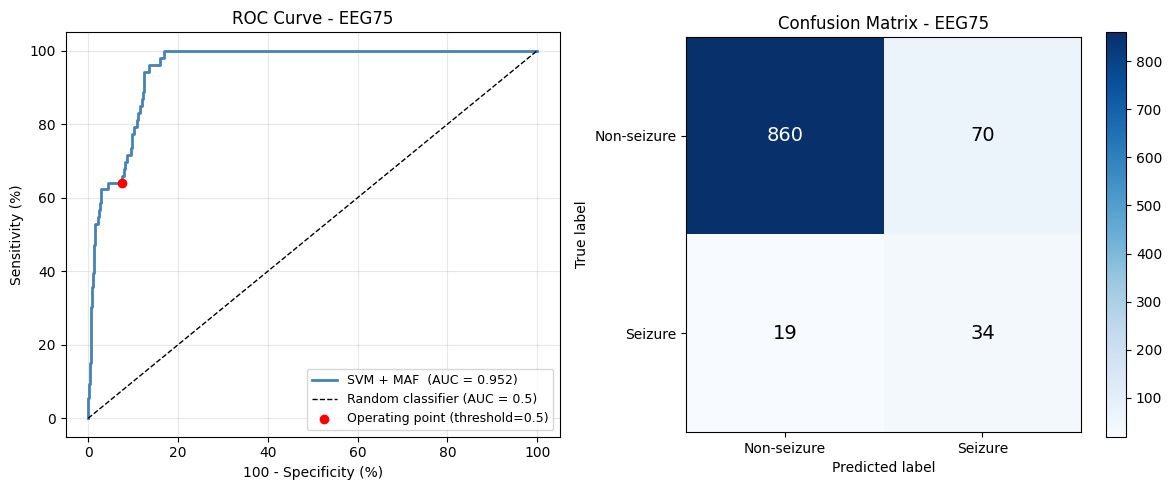

In [32]:
fpr, tpr, _ = roc_curve(y_test, proba_smooth)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve: plots sensitivity (y) vs 1-specificity (x) as threshold varies.
# Each point on the curve corresponds to a different decision threshold.
# The AUC summarises overall discrimination ability independently of threshold.
ax = axes[0]
ax.plot(fpr*100, tpr*100, color='steelblue', lw=2,
        label=f'SVM + MAF  (AUC = {auc:.3f})')
ax.plot([0, 100], [0, 100], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
ax.scatter([100 - specificity*100], [sensitivity*100], color='red', zorder=5,
           label=f'Operating point (threshold={THRESHOLD})')
ax.set_xlabel('100 - Specificity (%)')
ax.set_ylabel('Sensitivity (%)')
ax.set_title('ROC Curve - EEG75')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Confusion matrix: visual summary of classification outcomes
ax = axes[1]
im = ax.imshow(cm.astype(float), cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Non-seizure', 'Seizure'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Non-seizure', 'Seizure'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix - EEG75')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig('fig_eeg75_roc.png', dpi=120)
plt.show()


---
## 9. Analysis and Discussion

### 9.1 Performance

The system achieved **64.2% sensitivity and 92.5% specificity**
on the independent test patient EEG75, with a ROC AUC of 0.952.

The high specificity relative to sensitivity indicates the system is conservative. It
correctly rejects the large majority of non-seizure epochs but misses some seizures.

The high AUC indicates strong overall discrimination ability across all
possible thresholds, even if the specific operating point at threshold=0.5 shows
an imbalance between sensitivity and specificity. It can be seen from the ROC curve that a decrease in the threshold could increase sensitivity significantly without a huge reduction in specificity. Depending on the clinical use cases this could be desirable.

### 9.2 Effect of Post-Processing

The moving-average filter reduced the number of predicted seizure epochs from the
raw SVM output to the smoothed output (visible in Section 8.2). Brief isolated
probability spikes are diminished in effect while sustained high-probability regions are
preserved, reducing false positives without substantially affecting true detections.

### 9.3 Sources of Error

**False Positives:** Rhythmic background EEG activity and artefacts (electrode
disconnect, respiration, movement) share features with seizures, particularly
elevated RMS amplitude and low spectral edge frequency. Temko et al. (2011) found
45% of false detections were artefact-induced and 50% were background activity.

**False Negatives:** Low-amplitude focal seizures whose features overlap with
non-seizure background are the hardest to detect. Greene et al. (2008) showed
that high-amplitude generalised seizures are consistently easier to classify
correctly, with patient-level sensitivity ranging from 52% to 100% depending
on seizure amplitude and type.

### 9.4 Limitations

- **No LOO cross-validation:** Leave-one-out cross-validation across all
  12 training patients could provide a more rigorous estimate of generalisation
  performance.
- **No artefact rejection:** A parallel artefact classifier would substantially
  reduce false positives. Temko et al. (2011) found 45% of false alarms were
  artefact-driven.
- **Single channel test:** Only Cz-C3 is available for EEG75. A full 8-channel
  system with OR-fusion across channels would likely improve sensitivity.
- **Default hyperparameters:** C and gamma use scikit-learn defaults rather than
  an explicit grid search, which could further improve performance.


---
## 10. Conclusion

A patient-independent neonatal EEG seizure detection system was implemented in Python following the ANSeR algorithm architecture (Temko et al. 2011). The system was trained on 12 patients and evaluated on the completely independent test patient EEG75, satisfying the patient-independence requirement of the assignment.
The four-stage pipeline (epoch segmentation into 8-second windows, extraction of 9 targeted features, RBF-kernel SVM classification with balanced class weighting, and moving-average post-processing) achieved 64.2% sensitivity, 92.5% specificity and a ROC AUC of 0.952 on the test recording. The 9 features were selected largely based on the individual feature performance analysis of Greene et al. (2008), covering time-domain energy, frequency-domain and entropy categories identified as most discriminative for neonatal seizure detection.
The high AUC indicates strong overall discrimination ability. The conservative operating point at threshold 0.5 favours specificity over sensitivity, which could be adjusted by lowering the threshold if clinical requirements prioritised seizure detection over false alarm reduction. Limitations include the absence of artefact rejection, single-channel testing, and the use of default SVM hyperparameters. Future work would incorporate LOO cross-validation, explicit artefact rejection, and multi-channel OR-fusion to improve sensitivity.
